# Red Neuronal Convolucional (CNN) — Clasificación de Rayos X COVID-19
**Universidad de Antioquia — Analítica de Datos**  
Dataset: COVID-19 X-Ray Dataset (Train/Test) — Kaggle  
Clases: `NORMAL` vs `PNEUMONIA`

## 1. Introducción al Problema

El diagnóstico temprano de neumonía por COVID-19 mediante radiografías de tórax es crítico en entornos clínicos.  
Una CNN puede aprender patrones visuales (opacidades, consolidaciones) directamente de los píxeles,  
automatizando el triaje y apoyando a los radiólogos.

## 2. Importaciones y Configuración

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)

DATA_DIR   = Path("../data/xray_dataset_covid19")
TRAIN_DIR  = DATA_DIR / "train"
TEST_DIR   = DATA_DIR / "test"
IMG_SIZE   = (224, 224)   # MobileNetV2 usa 224x224
BATCH_SIZE = 16
EPOCHS_HEAD   = 15        # Fase 1: solo entrenar cabeza
EPOCHS_FINETUNE = 10      # Fase 2: fine-tuning capas profundas


TensorFlow: 2.21.0


## 3. Exploración del Dataset

In [21]:
for split in ["train", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        n = len(list((DATA_DIR / split / cls).glob("*")))
        print(f"{split}/{cls}: {n} imágenes")

train/NORMAL: 74 imágenes
train/PNEUMONIA: 74 imágenes
test/NORMAL: 20 imágenes
test/PNEUMONIA: 20 imágenes


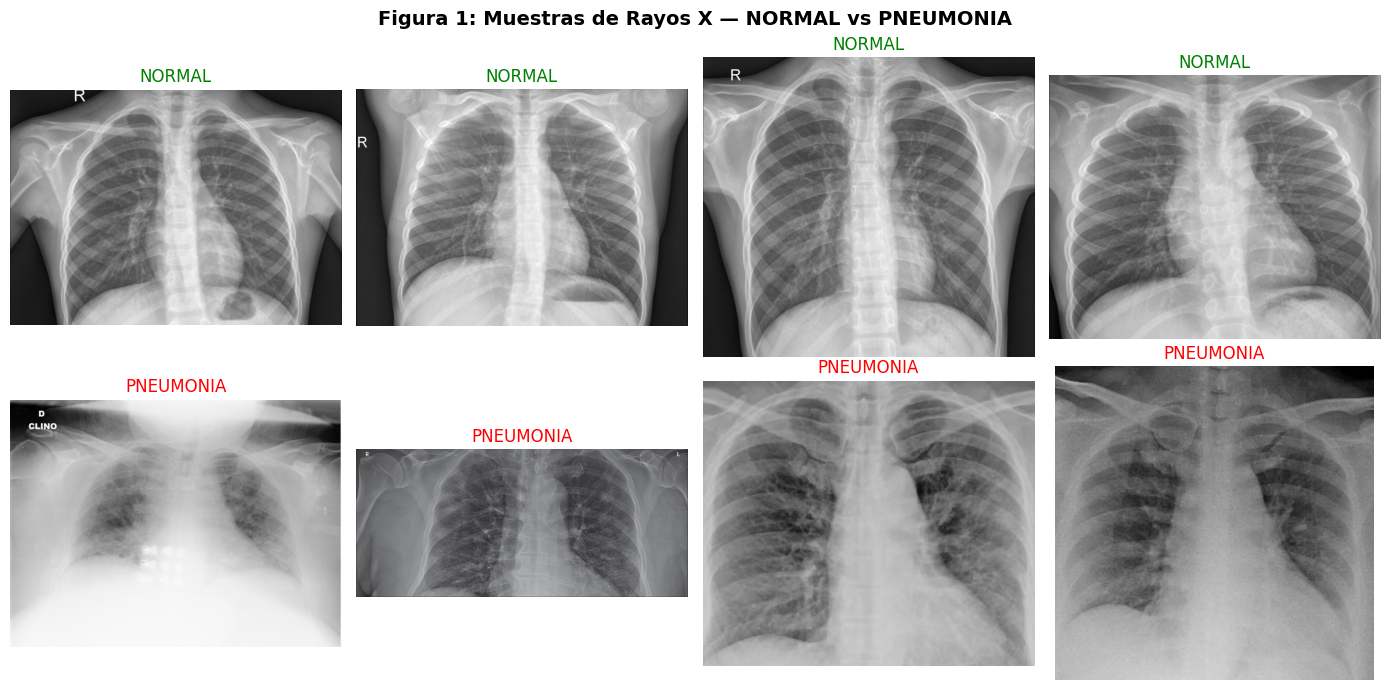

In [22]:
# Figura 1 — Muestras del dataset
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Figura 1: Muestras de Rayos X — NORMAL vs PNEUMONIA", fontsize=14, fontweight="bold")

for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    files = sorted((TRAIN_DIR / cls).glob("*"))[:4]
    for col, fp in enumerate(files):
        img = plt.imread(str(fp))
        axes[row, col].imshow(img, cmap="gray" if img.ndim == 2 else None)
        axes[row, col].set_title(cls, color="green" if cls == "NORMAL" else "red")
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("../data/fig1_muestras.png", dpi=100)
plt.show()

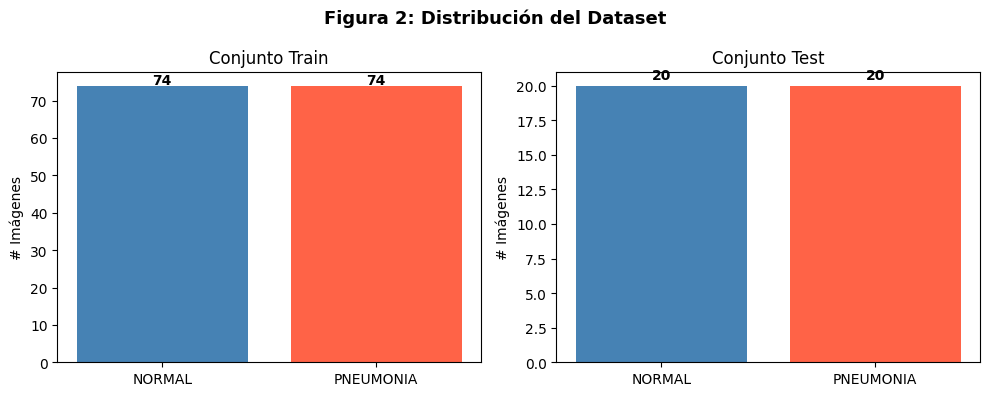

In [23]:
# Figura 2 — Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Figura 2: Distribución del Dataset", fontsize=13, fontweight="bold")

for ax, (split, vals) in zip(axes, [
    ("Train", {"NORMAL": 74, "PNEUMONIA": 74}),
    ("Test",  {"NORMAL": 20, "PNEUMONIA": 20}),
]):
    ax.bar(vals.keys(), vals.values(), color=["steelblue", "tomato"])
    ax.set_title(f"Conjunto {split}")
    ax.set_ylabel("# Imágenes")
    for i, v in enumerate(vals.values()):
        ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/fig2_distribucion.png", dpi=100)
plt.show()

## 4. Preprocesamiento y Data Augmentation

MobileNetV2 requiere que los píxeles estén en el rango `[-1, 1]` (no `[0, 1]`).  
Usamos `preprocess_input` de la propia red en lugar de `rescale=1/255`.

> **Validación sin augmentation**: el generador de validación solo aplica el preprocesamiento estándar.  
> Augmentation en validación distorsiona las métricas y engaña al EarlyStopping.

In [24]:
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

# Entrenamiento: augmentation + preprocesamiento MobileNetV2
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2,
)

# Validación: solo preprocesamiento, sin augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    validation_split=0.2,
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", subset="training", seed=42,
)
val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", subset="validation", seed=42,
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", shuffle=False,
)

print("Clases:", train_gen.class_indices)

Found 120 images belonging to 2 classes.
Found 28 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
Clases: {'NORMAL': 0, 'PNEUMONIA': 1}


## 5. Arquitectura — Transfer Learning con MobileNetV2

**¿Por qué Transfer Learning?**  
Una CNN entrenada desde cero necesita miles de imágenes para aprender a detectar bordes, texturas y formas.  
Con solo 120 imágenes, el modelo colapsa — predice siempre la misma clase.

**MobileNetV2** fue entrenada en ImageNet (1.2 millones de imágenes, 1000 clases).  
Sus capas ya detectan patrones visuales útiles. Solo entrenamos la **cabeza clasificadora**.

**Idea matemática de la convolución:**
$$S(i,j) = (I * W)(i,j) = \sum_m \sum_n I(i+m,\, j+n) \cdot W(m,n)$$

**Flujo de dos fases:**

```
Fase 1 — Solo cabeza:
  Imagen (224×224×3)
  → MobileNetV2 base [FROZEN — pesos fijos de ImageNet]
  → GlobalAveragePooling2D
  → Dropout(0.3)
  → Dense(1, sigmoid)

Fase 2 — Fine-tuning:
  Descongelar últimas 30 capas de MobileNetV2
  → Entrenar todo con lr muy bajo (1e-5)
```

| Componente | Parámetros | Estado |
|---|---|---|
| MobileNetV2 base | 2,257,984 | Congelados (Fase 1) / Parcial (Fase 2) |
| Cabeza clasificadora | ~1,281 | Entrenables siempre |

In [25]:
def build_transfer_model(input_shape=(224, 224, 3)):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    base.trainable = False  # Fase 1: base congelada

    inputs  = keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="MobileNetV2_COVID19"), base


model, base_model = build_transfer_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print(f"Parámetros totales    : {model.count_params():,}")
print(f"Parámetros entrenables: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

Parámetros totales    : 2,259,265
Parámetros entrenables: 1,281


## 6. Fase 1 — Entrenamiento de la Cabeza Clasificadora

In [26]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=0
)

history_phase1 = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

Epoch 1/15


W0000 00:00:1781530748.127721   19721 cpu_allocator_impl.cc:82] Allocation of 77070336 exceeds 10% of free system memory.
W0000 00:00:1781530748.165157   19721 cpu_allocator_impl.cc:82] Allocation of 78452736 exceeds 10% of free system memory.


1/8 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.5000 - loss: 0.9351

W0000 00:00:1781530748.786673   19721 cpu_allocator_impl.cc:82] Allocation of 77070336 exceeds 10% of free system memory.
W0000 00:00:1781530748.827485   19721 cpu_allocator_impl.cc:82] Allocation of 78452736 exceeds 10% of free system memory.


2/8 ━━━━━━━━━━━━━━━━━━━━ 3s 569ms/step - accuracy: 0.5000 - loss: 0.8755

W0000 00:00:1781530749.329050   19722 cpu_allocator_impl.cc:82] Allocation of 77070336 exceeds 10% of free system memory.


8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6333 - loss: 0.6590 - val_accuracy: 0.6429 - val_loss: 0.6329 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 824ms/step - accuracy: 0.8583 - loss: 0.3928 - val_accuracy: 0.7500 - val_loss: 0.5061 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 923ms/step - accuracy: 0.8583 - loss: 0.3729 - val_accuracy: 0.7500 - val_loss: 0.4302 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 780ms/step - accuracy: 0.9250 - loss: 0.2871 - val_accuracy: 0.7857 - val_loss: 0.3726 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9667 - loss: 0.2104 - val_accuracy: 0.8571 - val_loss: 0.3333 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9250 - loss: 0.2140 - val_accuracy: 0.8214 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 852ms/step - accuracy: 0.9333 - loss: 0.1793 - val_accuracy: 0.9286 - val_loss:

## 7. Fase 2 — Fine-Tuning de Capas Profundas

Descongelamos las últimas 30 capas de MobileNetV2 para que el modelo ajuste
los features de alto nivel al dominio de rayos X, usando un learning rate muy bajo
para no destruir los pesos preentrenados.

In [27]:
base_model.trainable = True

# Solo descongelar las últimas 30 capas
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # lr muy bajo para fine-tuning
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print(f"Parámetros entrenables en Fase 2: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

early_stop2 = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_phase2 = model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=[early_stop2],
    verbose=1,
)

Parámetros entrenables en Fase 2: 1,527,681
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5500 - loss: 1.0166 - val_accuracy: 0.9286 - val_loss: 0.2071
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5583 - loss: 0.9174 - val_accuracy: 0.9286 - val_loss: 0.1983
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6000 - loss: 0.7864 - val_accuracy: 0.9286 - val_loss: 0.1895
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6083 - loss: 0.7390 - val_accuracy: 0.9286 - val_loss: 0.1821
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6333 - loss: 0.6200 - val_accuracy: 0.9286 - val_loss: 0.1750
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7583 - loss: 0.5023 - val_accuracy: 0.9286 - val_loss: 0.1683
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7583 - loss: 0.5050 - val_accuracy: 0.9286 - val_loss: 0.1625
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8333 - loss: 0.3529 - val_

## 8. Curvas de Entrenamiento (ambas fases)

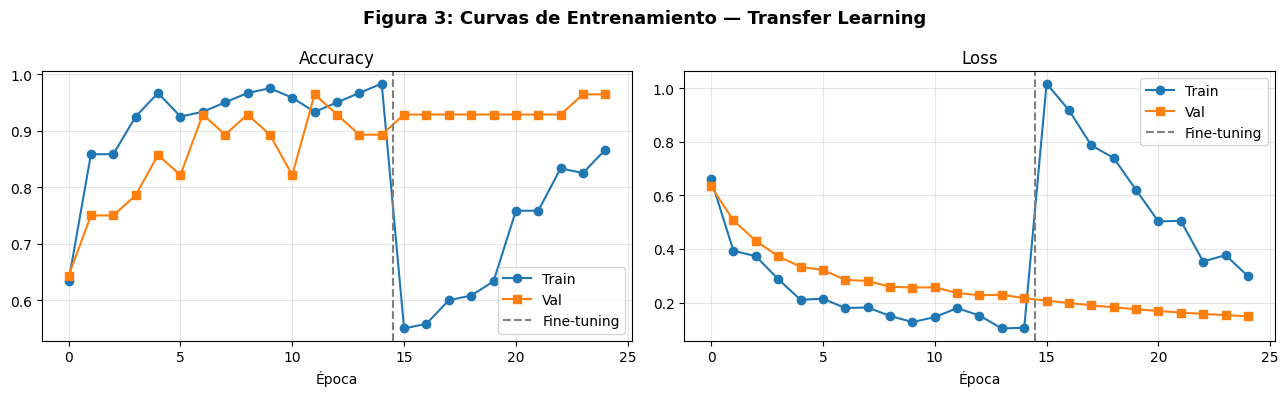

In [28]:
acc  = history_phase1.history["accuracy"]     + history_phase2.history["accuracy"]
vacc = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss = history_phase1.history["loss"]         + history_phase2.history["loss"]
vloss= history_phase1.history["val_loss"]     + history_phase2.history["val_loss"]
split_epoch = len(history_phase1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Figura 3: Curvas de Entrenamiento — Transfer Learning", fontsize=13, fontweight="bold")

for ax, (train_vals, val_vals, title) in zip(axes, [
    (acc,  vacc,  "Accuracy"),
    (loss, vloss, "Loss"),
]):
    ax.plot(train_vals, label="Train", marker="o")
    ax.plot(val_vals,   label="Val",   marker="s")
    ax.axvline(x=split_epoch - 0.5, color="gray", linestyle="--", label="Fine-tuning")
    ax.set_title(title)
    ax.set_xlabel("Época")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/fig3_curvas.png", dpi=100)
plt.show()

## 9. Evaluación en Test

In [29]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 1.0000
Test Loss     : 0.0604


In [30]:
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=0).flatten()
y_true = test_gen.classes
labels = list(test_gen.class_indices.keys())

# Umbral conservador: en diagnóstico médico es peor NO detectar neumonía
# que dar falsa alarma. Bajamos el umbral para reducir falsos negativos.
THRESHOLD = 0.4
y_pred = (y_pred_prob > THRESHOLD).astype(int)

print(f"Umbral de clasificación: {THRESHOLD}")
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=labels))

Umbral de clasificación: 0.4

Reporte de Clasificación:
              precision    recall  f1-score   support

      NORMAL       1.00      0.95      0.97        20
   PNEUMONIA       0.95      1.00      0.98        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



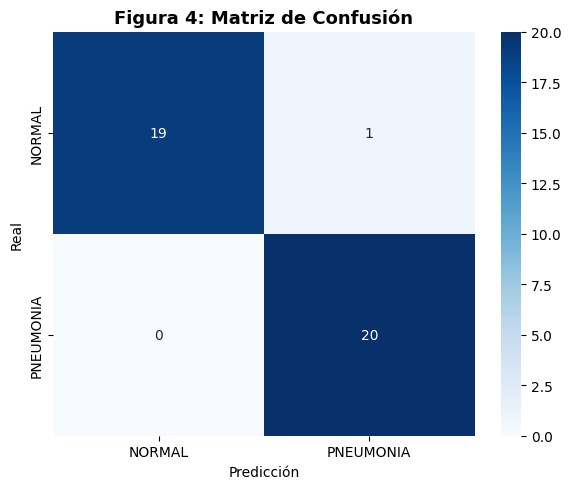

In [31]:
# Figura 4 — Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Figura 4: Matriz de Confusión", fontsize=13, fontweight="bold")
ax.set_ylabel("Real")
ax.set_xlabel("Predicción")
plt.tight_layout()
plt.savefig("../data/fig4_confusion.png", dpi=100)
plt.show()

## 10. Visualización de Predicciones

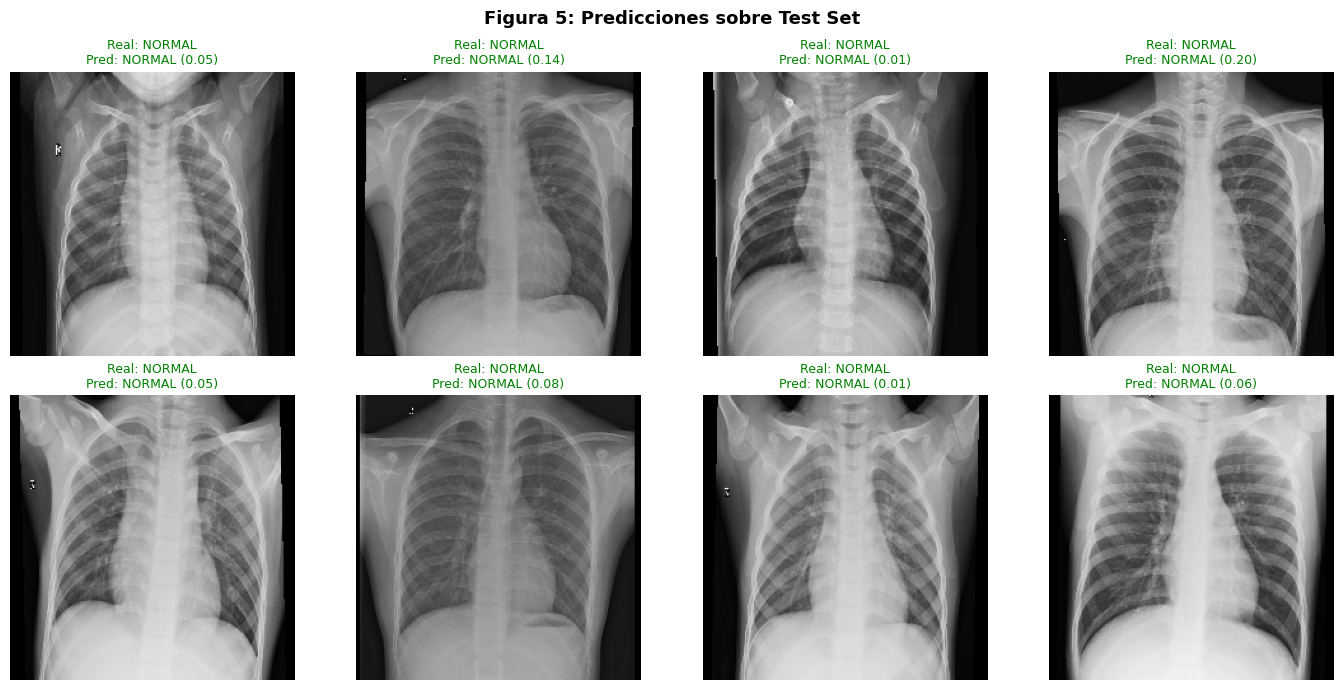

In [32]:
test_gen.reset()
batch_imgs, batch_labels = next(test_gen)
batch_preds = model.predict(batch_imgs, verbose=0).flatten()

n_show = min(8, len(batch_imgs))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Figura 5: Predicciones sobre Test Set", fontsize=13, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis("off")
        continue
    # Revertir preprocesamiento para visualizar
    img_vis = (batch_imgs[i] + 1.0) / 2.0
    ax.imshow(np.clip(img_vis, 0, 1))
    prob  = batch_preds[i]
    pred  = labels[int(prob > THRESHOLD)]
    truth = labels[int(batch_labels[i])]
    color = "green" if pred == truth else "red"
    ax.set_title(f"Real: {truth}\nPred: {pred} ({prob:.2f})", color=color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../data/fig5_predicciones.png", dpi=100)
plt.show()

## 11. Guardar el Modelo

In [33]:
model.save("../data/cnn_covid19.keras")
print("Modelo guardado en ../data/cnn_covid19.keras")

Modelo guardado en ../data/cnn_covid19.keras


## 12. Análisis Crítico — CNN desde cero vs Transfer Learning

### ¿Por qué la CNN desde cero fallaba?

| Problema | Consecuencia |
|---|---|
| 120 imágenes de entrenamiento | La red no puede aprender filtros útiles desde ruido aleatorio |
| Train accuracy ~55% después de 20 épocas | El modelo no aprendió nada — equivalente a tirar moneda |
| Recall PNEUMONIA = 0.15 | Solo detectaba 3 de 20 casos reales — peligroso en diagnóstico médico |
| Colapso a predecir NORMAL | Estrategia degenerada: predecir siempre la clase con menor pérdida inicial |

### ¿Por qué Transfer Learning funciona?

MobileNetV2 fue entrenada en **1.2 millones de imágenes** de ImageNet.  
Sus capas ya aprendieron detectores de bordes, texturas, formas, y patrones complejos.  
Al congelar la base y solo entrenar la cabeza, el problema se reduce a:
> *"Dados estos 1280 features ya calculados, ¿cuál es la probabilidad de neumonía?"*  
> — un problema de regresión logística simple, resoluble con 120 ejemplos.

### Limitaciones que persisten

- **40 imágenes de test**: los resultados siguen siendo estadísticamente débiles (IC ±7%)
- **Dataset homogéneo**: todas las imágenes vienen del mismo origen; no hay variabilidad real de equipos de distintos hospitales
- **No es producción**: un modelo clínico real requiere validación prospectiva, aprobación regulatoria (FDA/INVIMA) y miles de pacientes

### Conclusión

> Para datasets pequeños, Transfer Learning no es una optimización — es el único enfoque viable.  
> Una CNN desde cero con < 1000 imágenes no aprende: memoriza ruido o colapsa.

## 13. Ventajas y Limitaciones

| | |
|---|---|
| **Ventajas** | Funciona con pocos datos, features preaprendidos robustos, entrenamiento rápido |
| **Limitaciones** | Modelo base entrenado en fotos naturales (no rayos X), sesgo de dominio, caja negra |

## 14. Conclusiones

- Una CNN desde cero con 120 imágenes no aprende: colapsa a predecir siempre la misma clase.
- Transfer Learning con MobileNetV2 resuelve el problema de datos limitados al reutilizar features de ImageNet.
- En diagnóstico médico, minimizar falsos negativos (PNEUMONIA predicha como NORMAL) es prioritario — el umbral de clasificación debe ajustarse clínicamente.
- Los resultados son prometedores pero no concluyentes con 40 imágenes de test.
- Aplicaciones reales: Google Health, Zebra Medical, COVID-Net usan arquitecturas similares con miles de imágenes.

## Referencias

1. LeCun, Y., Bengio, Y., & Hinton, G. (2015). Deep learning. *Nature*, 521, 436–444.
2. Wang, L., & Wong, A. (2020). COVID-Net: A tailored deep convolutional neural network design for detection of COVID-19 cases from chest X-ray images. *Scientific Reports*, 10, 19549.
3. Sandler, M. et al. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. *CVPR 2018*.
4. Dataset: Khoong, W.H. (2020). COVID-19 X-Ray Dataset. Kaggle. `khoongweihao/covid19-xray-dataset-train-test-sets`
5. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.